Initialization & Loading Processed Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

# Set visualization style for high-quality corporate reporting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

# Load cleaned data
df = pd.read_csv("../data/processed/mtn_cleaned_customers.csv")
print(f"Dataset ready for EDA. Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset ready for EDA. Rows: 974, Columns: 17


In [2]:
df.head()

,Customer ID,Full Name,Date of Purchase,Age,State,MTN Device,Gender,Satisfaction Rate,Customer Review,Customer Tenure in months,Subscription Plan,Unit Price,Number of Times Purchased,Total Revenue,Data Usage,Customer Churn Status,Reasons for Churn
0,CUST0001,Ngozi Berry,2025-01-01,27,Kwara,4G Router,Male,2,Fair,2,165GB Monthly Plan,35000,19,665000,44.48,Yes,Relocation
1,CUST0002,Zainab Baker,2025-03-01,16,Abuja (Fct),Mobile SIM Card,Female,2,Fair,22,12.5GB Monthly Plan,5500,12,66000,19.79,Yes,Better Offers from Competitors
2,CUST0003,Saidu Evans,2025-03-01,21,Sokoto,5G Broadband Router,Male,1,Poor,60,150GB FUP Monthly Unlimited,20000,8,160000,9.64,No,Active Customer
3,CUST0003,Saidu Evans,2025-03-01,21,Sokoto,Mobile SIM Card,Male,1,Poor,60,1GB+1.5mins Daily Plan,500,8,4000,197.05,No,Active Customer
4,CUST0003,Saidu Evans,2025-03-01,21,Sokoto,Broadband MiFi,Male,1,Poor,60,30GB Monthly Broadband Plan,9000,15,135000,76.34,No,Active Customer


Value & Behavioral Distribution (The Segmentation Drivers)

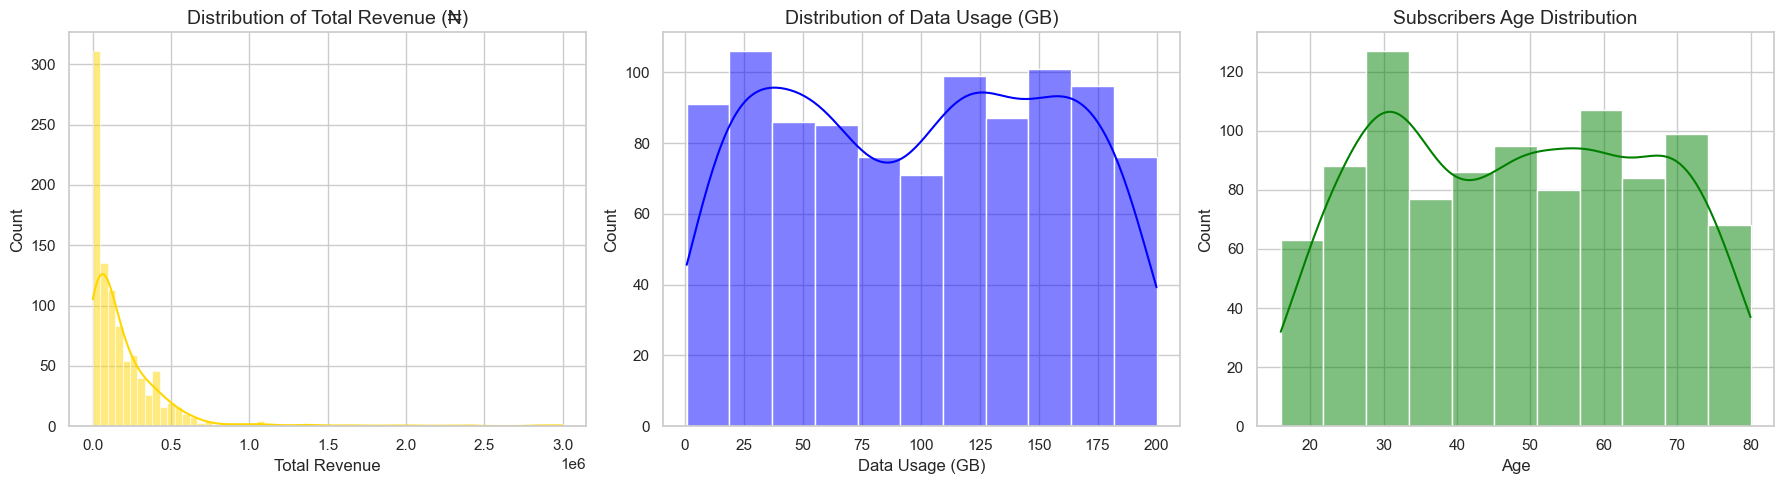

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Revenue Distribution
sns.histplot(df['Total Revenue'], kde=True, ax=axes[0], color='gold')
axes[0].set_title('Distribution of Total Revenue (₦)')
axes[0].set_xlabel('Total Revenue')

# Data Usage Distribution
sns.histplot(df['Data Usage'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Distribution of Data Usage (GB)')
axes[1].set_xlabel('Data Usage (GB)')

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Subscribers Age Distribution')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

Correlation Matrix Matrix (Identifying Multicollinearity)

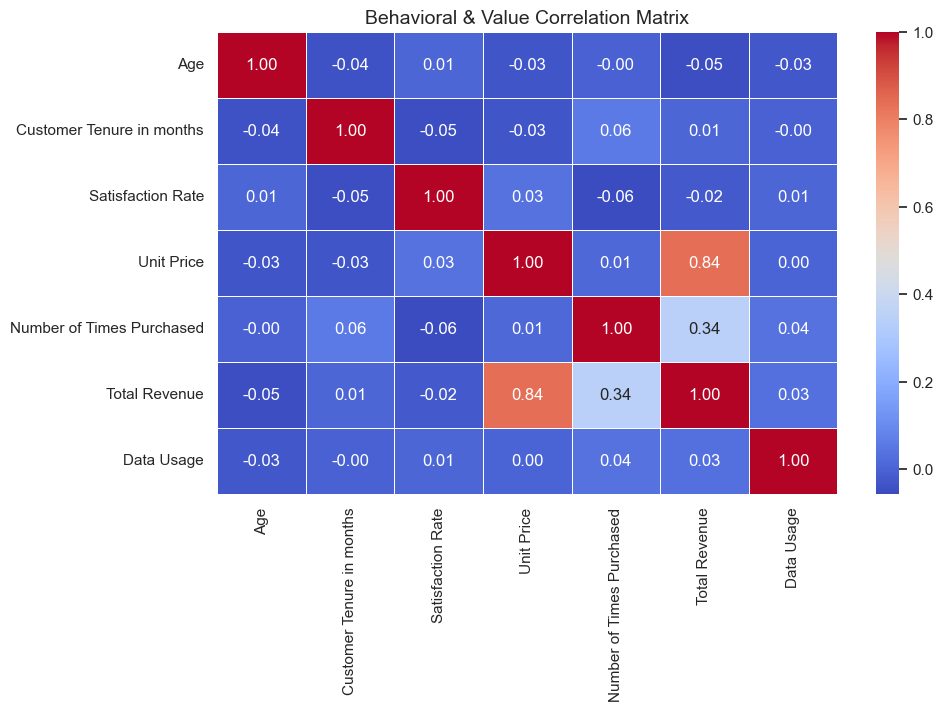

In [4]:
# Selecting numeric features relevant to customer behavior and lifecycle value
numeric_features = ['Age', 'Customer Tenure in months', 'Satisfaction Rate', 
                    'Unit Price', 'Number of Times Purchased', 'Total Revenue', 'Data Usage']

corr_matrix = df[numeric_features].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Behavioral & Value Correlation Matrix')
plt.show()

Categorical Cross-Analysis (Device Tiers vs. Value)

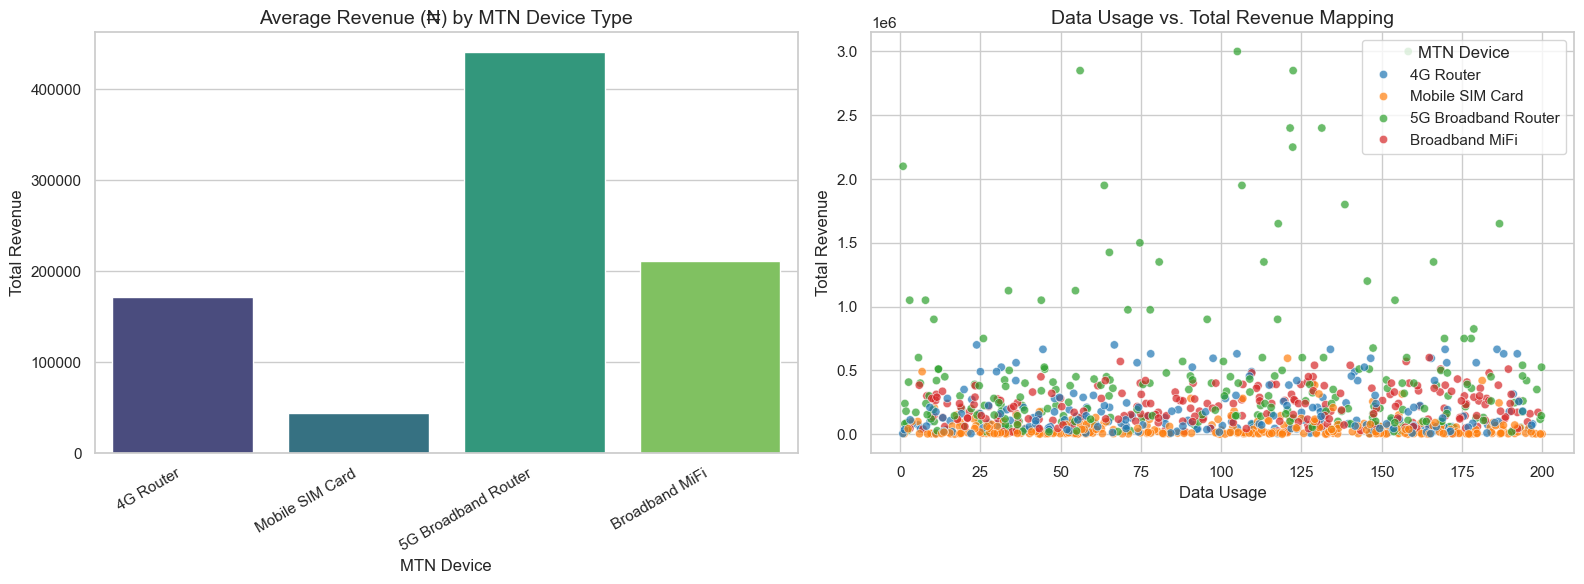

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average Revenue by Device Type
sns.barplot(data=df, x='MTN Device', y='Total Revenue', ax=axes[0], errorbar=None, palette='viridis')
axes[0].set_title('Average Revenue (₦) by MTN Device Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# 2. Data Usage vs Total Revenue colored by Device Type
sns.scatterplot(data=df, x='Data Usage', y='Total Revenue', hue='MTN Device', alpha=0.7, ax=axes[1], palette='tab10')
axes[1].set_title('Data Usage vs. Total Revenue Mapping')

plt.tight_layout()
plt.show()

Customer Health & Sentiment EDA

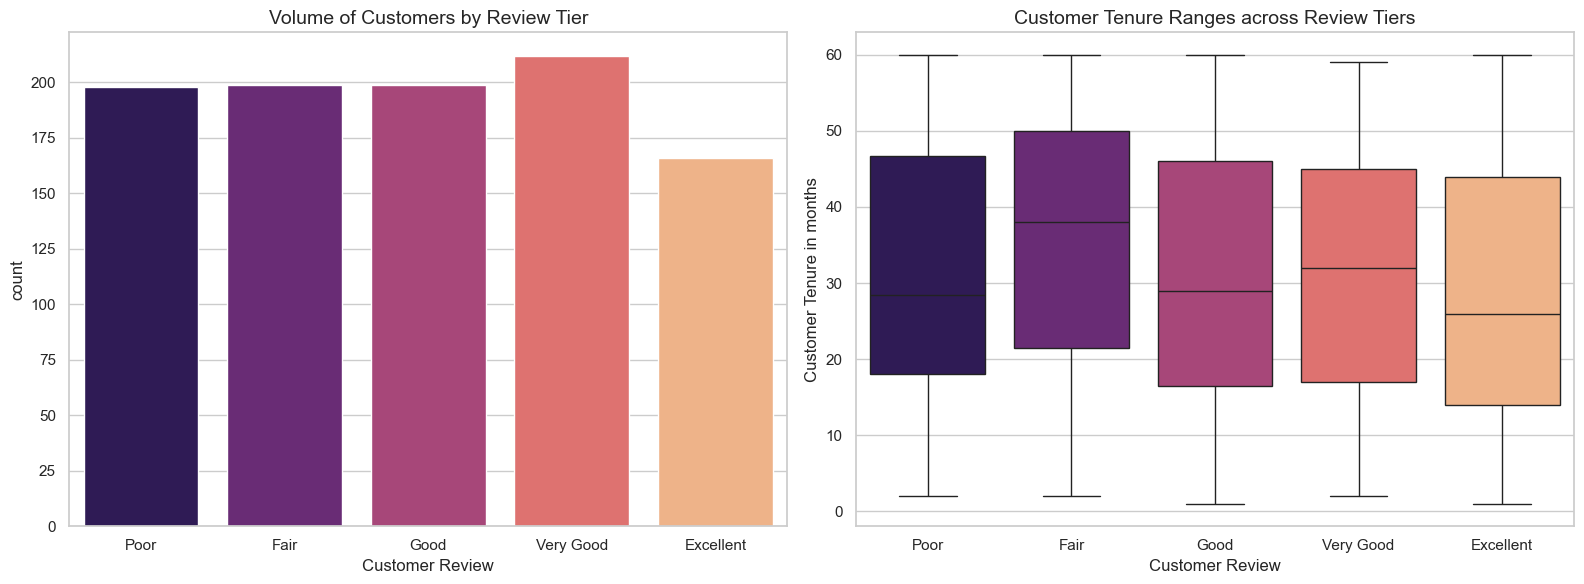

In [11]:
# Ordering the reviews logically from worst to best
review_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Customer Reviews across the base
sns.countplot(data=df, x='Customer Review', order=review_order, ax=axes[0], palette='magma')
axes[0].set_title('Volume of Customers by Review Tier')

# Satisfaction Rate vs. Tenure grouped by Churn Status (to see historical sentiment patterns)
sns.boxplot(data=df, x='Customer Review', y='Customer Tenure in months', order=review_order, ax=axes[1], palette='magma')
axes[1].set_title('Customer Tenure Ranges across Review Tiers')

plt.tight_layout()
plt.show()

Regional Spender Profiling (Top States by Revenue)

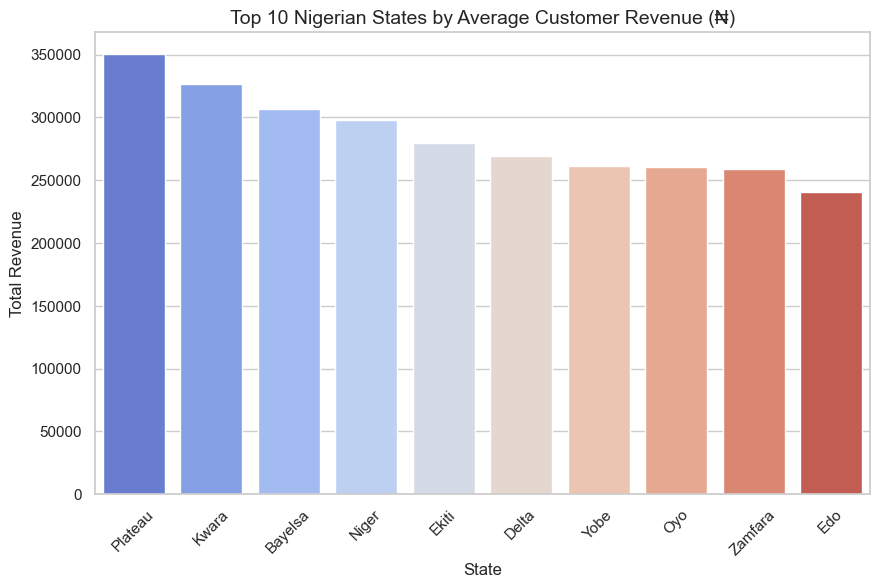

In [12]:
# Calculating top 10 states by average revenue
top_states = df.groupby('State')['Total Revenue'].mean().sort_values(ascending=False).head(10).index

df_top_states = df[df['State'].isin(top_states)]

sns.barplot(data=df_top_states, x='State', y='Total Revenue', order=top_states, errorbar=None, palette='coolwarm')
plt.title('Top 10 Nigerian States by Average Customer Revenue (₦)')
plt.xticks(rotation=45)
plt.show()

Feature Engineering & Matrix Scaling

In [13]:
# Mapping Device Types to an Ordinal Tier based on network infrastructure level
device_tier_map = {
    'Mobile SIM Card': 1,
    'Broadband MiFi': 2,
    '4G Router': 3,
    '5G Broadband Router': 4
}
df['Device_Tier'] = df['MTN Device'].map(device_tier_map)

# Isolating core columns for clustering (Value, Behavior, Demographics, Sentiment)
cluster_features = [
    'Age', 
    'Customer Tenure in months', 
    'Satisfaction Rate', 
    'Unit Price', 
    'Data Usage', 
    'Total Revenue', 
    'Device_Tier'
]

X = df[cluster_features].copy()

# Standardizing features to a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete! Input shape for clustering:", X_scaled.shape)

Scaling complete! Input shape for clustering: (974, 7)


Running the Elbow Method and Silhouette Evaluation

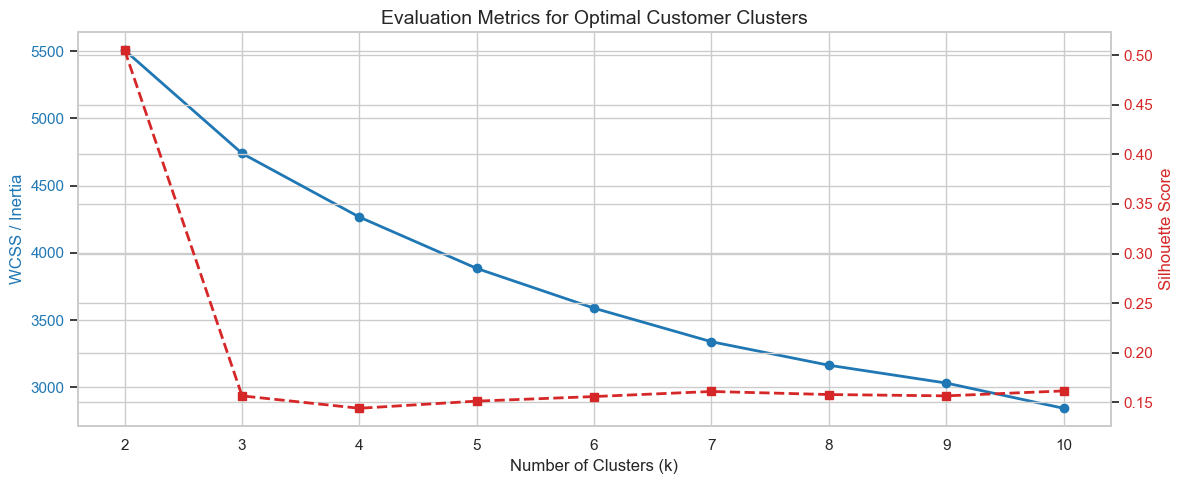

In [14]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plotting the Evaluation Metrics
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot WCSS (Elbow)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS / Inertia', color=color)
ax1.plot(k_range, wcss, 'o-', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Evaluation Metrics for Optimal Customer Clusters')

# Instantiate a second axes that shares the same x-axis for Silhouette Score
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, 's--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

Fit the Final K-Means Model and Assign Segments

In [15]:
# Train the final K-Means model with K=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Predict and assign cluster labels to our original DataFrame
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster assignment complete! Value counts per segment:")
print(df['Cluster'].value_counts())

Cluster assignment complete! Value counts per segment:
Cluster
0    351
3    293
1    292
2     38
Name: count, dtype: int64


Profile the Segments (The Corporate Persona Blueprint)

In [16]:
# Aggregating key metrics across clusters to identify characteristics
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Customer Tenure in months': 'mean',
    'Total Revenue': 'mean',
    'Data Usage': 'mean',
    'Satisfaction Rate': 'mean',
    'MTN Device': lambda x: x.mode()[0],
    'Subscription Plan': lambda x: x.mode()[0] 
}).reset_index()

# Renaming columns for executive presentation
cluster_profile.columns = [
    'Cluster ID', 'Avg Age', 'Avg Tenure (Months)', 
    'Avg Revenue (₦)', 'Avg Data Usage (GB)', 'Avg Satisfaction', 
    'Dominant Device', 'Dominant Plan'
]

# Display the profile table sorted by revenue
cluster_profile.sort_values(by='Avg Revenue (₦)', ascending=False)

,Cluster ID,Avg Age,Avg Tenure (Months),Avg Revenue (₦),Avg Data Usage (GB),Avg Satisfaction,Dominant Device,Dominant Plan
2,2,43.421053,30.131579,1.419079e+06,92.327895,3.078947,5G Broadband Router,1.5TB Yearly Broadband Plan
3,3,47.317406,47.812287,2.156075e+05,104.759727,2.901024,4G Router,150GB FUP Monthly Unlimited
1,1,51.708904,15.510274,2.069384e+05,91.769897,3.246575,4G Router,150GB FUP Monthly Unlimited
0,0,46.099715,31.119658,6.217721e+04,101.774843,2.723647,Mobile SIM Card,12.5GB Monthly Plan


Summary

### The 4 Customer Personas

* **Cluster 2: "The Enterprise Power Users" (38 Customers)**
  * **The Profile:** High spending, massive data consumption (92.3 GB average), utilizing premium 5G Broadband Routers on 1.5TB Yearly plans.
  * **Revenue Impact:** Average revenue of **₦1,419,079** per customer! This small group is an incredibly heavy revenue anchor for the business.

* **Cluster 3: "The Heavy Data Hubs" (293 Customers)**
  * **The Profile:** Average revenue of **₦215,607**, but with the highest average data consumption in the entire dataset (104.75 GB). They are dominant on 4G Routers with Monthly Unlimited plans.

* **Cluster 1: "The Maturing Loyalists" (292 Customers)**
  * **The Profile:** Average revenue of **₦206,938** with 91.76 GB of data usage. They match Cluster 3 closely but have much lower average tenure (15.5 months vs. 47.8 months), representing a rapidly growing mid-tier router user base.

* **Cluster 0: "The Retail Mobile Base" (351 Customers)**
  * **The Profile:** The largest customer segment by volume. They have an average revenue of **₦62,177**, utilizing standard Mobile SIM Cards on standard 12.5GB Monthly Plans.

Export the Segmented Dataset

In [17]:
df.to_csv("../data/processed/mtn_segmented_customers.csv", index=False)
print("Segmented dataset successfully saved to 'data/processed/mtn_segmented_customers.csv'")

Segmented dataset successfully saved to 'data/processed/mtn_segmented_customers.csv'
